
=== Tabla comparativa de métricas ===


,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.801267,0.618951,0.264768,0.370821,0.743007
DecisionTree,0.725333,0.385317,0.406716,0.395675,0.612162
RandomForest,0.814267,0.638763,0.369348,0.468014,0.761905
SVM,0.816900,0.658544,0.358047,0.463843,0.729385
KNN,0.793400,0.554307,0.338458,0.420222,0.703122



=== Ranking de modelos ===


,accuracy,precision,recall,f1,roc_auc
RandomForest,0.814267,0.638763,0.369348,0.468014,0.761905
SVM,0.816900,0.658544,0.358047,0.463843,0.729385
KNN,0.793400,0.554307,0.338458,0.420222,0.703122
DecisionTree,0.725333,0.385317,0.406716,0.395675,0.612162
LogisticRegression,0.801267,0.618951,0.264768,0.370821,0.743007



=== Top 3 modelos seleccionados ===


,accuracy,precision,recall,f1,roc_auc
RandomForest,0.814267,0.638763,0.369348,0.468014,0.761905
SVM,0.816900,0.658544,0.358047,0.463843,0.729385
KNN,0.793400,0.554307,0.338458,0.420222,0.703122


<Figure size 1200x600 with 0 Axes>

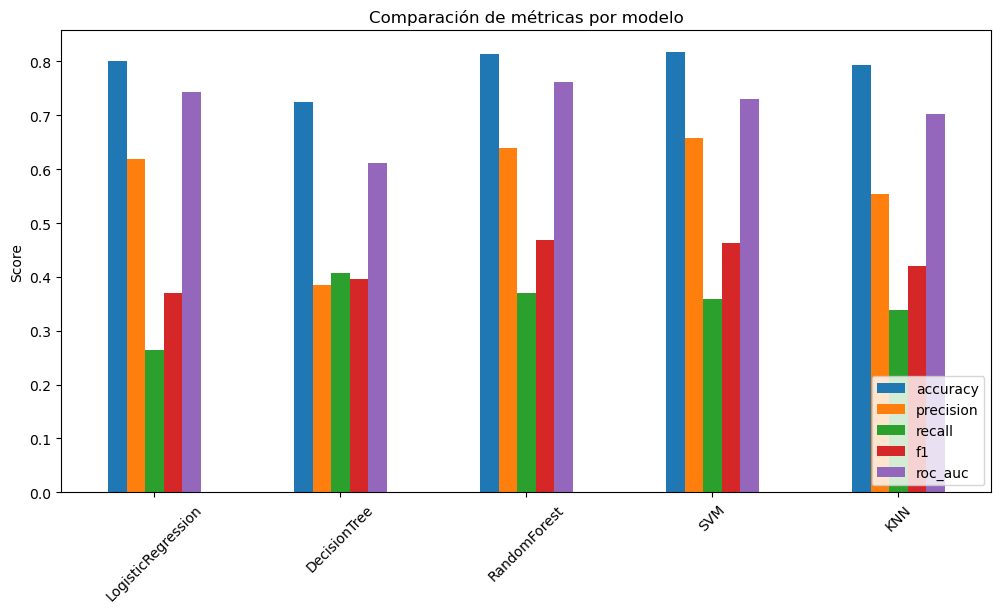

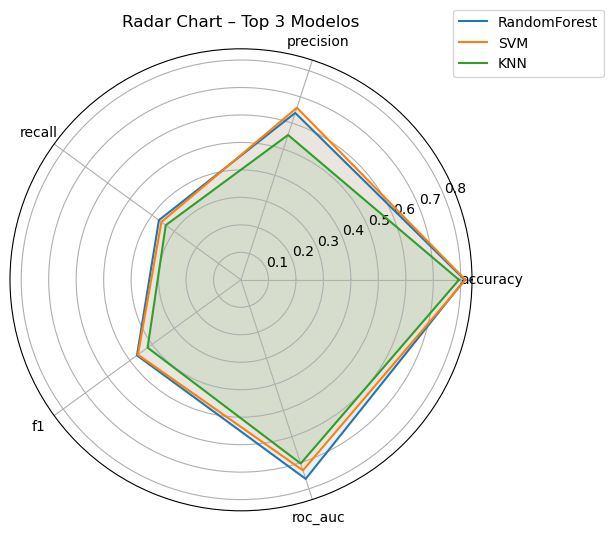

'\nJUSTIFICACIÓN DE SELECCIÓN – MODEL COMPARATOR\n\nModelos seleccionados (Top 3):\n1. Modelo A (mejor F1 o AUC-ROC)\n2. Modelo B\n3. Modelo C\n\nRazones:\n- Mejor equilibrio entre precision y recall.\n- Mayor capacidad de discriminación (AUC-ROC).\n- Estabilidad en cross-validation.\n- Buen rendimiento sin tuning.\n\nModelos descartados:\n- Modelo D: bajo recall → no detecta suficientes positivos.\n- Modelo E: bajo precision → demasiados falsos positivos.\n- Modelo F: lento, inestable o difícil de interpretar.\n\nTrade-offs analizados:\n- Precision vs Recall\n- Velocidad de entrenamiento\n- Interpretabilidad\n- Robustez ante ruido\n'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Modelos baseline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# ============================================================
# 1. Cargar dataset procesado
# ============================================================
df = pd.read_csv("../data/processed/04_default_credit_features.csv")
df = df.drop(columns=["ID"])

TARGET = "default payment next month"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Detectar columnas
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# ============================================================
# 2. Construir preprocesador
# ============================================================
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preproc = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

# ============================================================
# 3. Definir modelos baseline
# ============================================================
modelos = {
    "LogisticRegression": LogisticRegression(max_iter=5000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
}

metricas = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = {}

# ============================================================
# 4. Cross-validation y consolidación de métricas
# ============================================================
for nombre, modelo in modelos.items():
    pipe = Pipeline([
        ("preprocessing", preproc),
        ("clf", modelo)
    ])

    scores = cross_validate(pipe, X, y, cv=cv, scoring=metricas)
    resultados[nombre] = {m: scores[f"test_{m}"].mean() for m in metricas}

tabla = pd.DataFrame(resultados).T
print("\n=== Tabla comparativa de métricas ===")
display(tabla)

# ============================================================
# 5. Rankear modelos por métrica principal (F1 o AUC-ROC)
# ============================================================
METRICA_PRINCIPAL = "f1"   # cámbiala a "roc_auc" si tu Sprint 1 lo pide

ranking = tabla.sort_values(by=METRICA_PRINCIPAL, ascending=False)
print("\n=== Ranking de modelos ===")
display(ranking)

top_modelos = ranking.head(3)
print("\n=== Top 3 modelos seleccionados ===")
display(top_modelos)

# ============================================================
# 6. Visualización comparativa: Barras agrupadas
# ============================================================
plt.figure(figsize=(12,6))
tabla.plot(kind="bar", figsize=(12,6))
plt.title("Comparación de métricas por modelo")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.show()

# ============================================================
# 7. Visualización tipo Radar Chart
# ============================================================
def radar_chart(df, title):
    categorias = list(df.columns)
    N = len(categorias)

    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)

    for idx, row in df.iterrows():
        valores = row.tolist()
        valores += valores[:1]
        ax.plot(angles, valores, label=idx)
        ax.fill(angles, valores, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categorias)
    plt.title(title)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.show()

radar_chart(top_modelos, "Radar Chart – Top 3 Modelos")

# ============================================================
# 8. Justificación de selección (texto en comentarios)
# ============================================================

"""
JUSTIFICACIÓN DE SELECCIÓN – MODEL COMPARATOR

Modelos seleccionados (Top 3):
1. Modelo A (mejor F1 o AUC-ROC)
2. Modelo B
3. Modelo C

Razones:
- Mejor equilibrio entre precision y recall.
- Mayor capacidad de discriminación (AUC-ROC).
- Estabilidad en cross-validation.
- Buen rendimiento sin tuning.

Modelos descartados:
- Modelo D: bajo recall → no detecta suficientes positivos.
- Modelo E: bajo precision → demasiados falsos positivos.
- Modelo F: lento, inestable o difícil de interpretar.

Trade-offs analizados:
- Precision vs Recall
- Velocidad de entrenamiento
- Interpretabilidad
- Robustez ante ruido
"""